In [1]:
from rnd_spectra.bumps import Bumps
from rnd_spectra.ontheflydataset import OnTheFlyDataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
sns.set_theme(style="ticks",palette='tab10',rc={'axes.labelsize':14})
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
hparams = {
    'omega_domain': (0, 50.0),
    'num_bumps_range': (1,4), 
    'bump_widths_fraction_range': (0.1, 0.6), 
    'bump_centers_fraction_range': (0.0, 0.5)
}
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 1, 99])


In [3]:
hparams = {
    'omega_domain': (0, 50.0),
    'num_bumps_range': (1,4), 
    'bump_widths_fraction_range': (0.1, 0.6), 
    'bump_centers_fraction_range': (0.0, 0.5)
}
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9, pointwise_norm=True)
test_norm_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test_norm in test_norm_loader:
    print(C_test.size(),G_test_norm.size())

torch.Size([9, 1, 1024]) torch.Size([9, 4, 99])


In [3]:
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=10000)
dataloader = DataLoader(dataset, batch_size=1000, shuffle=False,num_workers=0)
tau = dataloader.dataset.laplace.tau
omega = dataloader.dataset.laplace.omega

In [8]:
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=10000, pointwise_norm=True)#,channel_mean=torch.Tensor([0., 0., 0., 0.]), channel_std=torch.Tensor([1., 1., 1., 1.]))
dataloader_norm = DataLoader(dataset, batch_size=1000, shuffle=False,num_workers=0)

In [9]:
m = 10
L = len(dataloader_norm)
channel_mean = channel_std = 0
for i in tqdm(range(m)):
    for CC, GG in dataloader_norm:
        channel_mean += GG.mean((0,2))/L/m
for i in tqdm(range(m)):
    for CC, GG in dataloader_norm:
        channel_std += ((GG-channel_mean.unsqueeze(0).unsqueeze(-1))**2).mean((0,2))/L/m
channel_std = channel_std.sqrt()

100%|██████████| 10/10 [01:57<00:00, 11.79s/it]


In [10]:
channel_mean, channel_std

(tensor([-1.3674e-05,  1.6385e-04,  1.5603e-04, -1.9042e-04]),
 tensor([1.0016, 1.0010, 1.0011, 1.0010]))

In [7]:
channel_mean, channel_std

(tensor([ 0.3319, -1.8394,  0.0023,  0.5002]),
 tensor([0.4170, 1.5327, 1.1582, 0.2884]))

In [18]:
m = 10
L = len(dataloader)
channel_mean = channel_std = 0
for i in tqdm(range(m)):
    for CC, GG in dataloader_norm:
        channel_mean += GG.mean((0,2))/L/m
for i in tqdm(range(m)):
    for CC, GG in dataloader_norm:
        channel_std += ((GG-channel_mean)**2).mean((0,2))/L/m

tensor([0.5108, 2.1259, 1.1557, 0.2926])
tensor([0.4984, 2.0791, 1.1550, 0.2920])
tensor([0.4914, 2.0313, 1.1517, 0.2914])
tensor([0.4860, 2.0158, 1.1647, 0.2939])
tensor([0.4979, 2.0569, 1.1460, 0.2902])
tensor([0.5029, 2.0796, 1.1374, 0.2885])
tensor([0.5033, 2.0695, 1.1514, 0.2901])
tensor([0.5075, 2.1180, 1.1449, 0.2897])
tensor([0.4990, 2.0221, 1.1213, 0.2828])
tensor([0.5060, 2.1024, 1.1421, 0.2895])


In [7]:
m = 10
L = len(dataloader)
pointwise_mean_G = 0
pointwise_mean_abd_G = 0 # pointwise mean absolute deviation
pointwise_mean_std_G = 0
for i in tqdm(range(m)):
    for C, G in dataloader:
        pointwise_mean_G += G.mean(dim=0) / (L * m)
for i in tqdm(range(m)):
    for C, G in dataloader:
        pointwise_mean_abd_G += (G - pointwise_mean_G.unsqueeze(0)).abs().mean(dim=0) / (L * m)
        pointwise_mean_std_G += ((G - pointwise_mean_G.unsqueeze(0))**2).sum(dim=0) / (L * m)
pointwise_mean_std_G = torch.sqrt(pointwise_mean_std_G)

100%|██████████| 10/10 [01:37<00:00,  9.73s/it]


In [ ]:
# np.save('rnd_spectra/pointwise_mean_G', pointwise_mean_G.cpu().detach().numpy())
# np.save('rnd_spectra/pointwise_mean_abd_G', pointwise_mean_abd_G.cpu().detach().numpy())

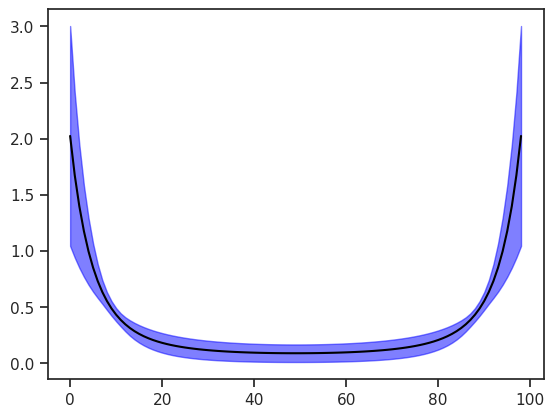

In [100]:
plt.plot(pointwise_mean_G.cpu().detach().numpy().flatten(), color='k')
plt.fill_between(np.arange(99),(pointwise_mean_G - pointwise_mean_abd_G).cpu().detach().numpy().flatten(),
                 (pointwise_mean_G + pointwise_mean_abd_G).cpu().detach().numpy().flatten(),
                 color='blue', alpha=0.5)
# plt.plot(pointwise_mean_abd_G.cpu().detach().numpy().flatten(), color='k', linestyle='--')
# plt.plot(pointwise_mean_std_G.cpu().detach().numpy().flatten(), color='k', linestyle='--')

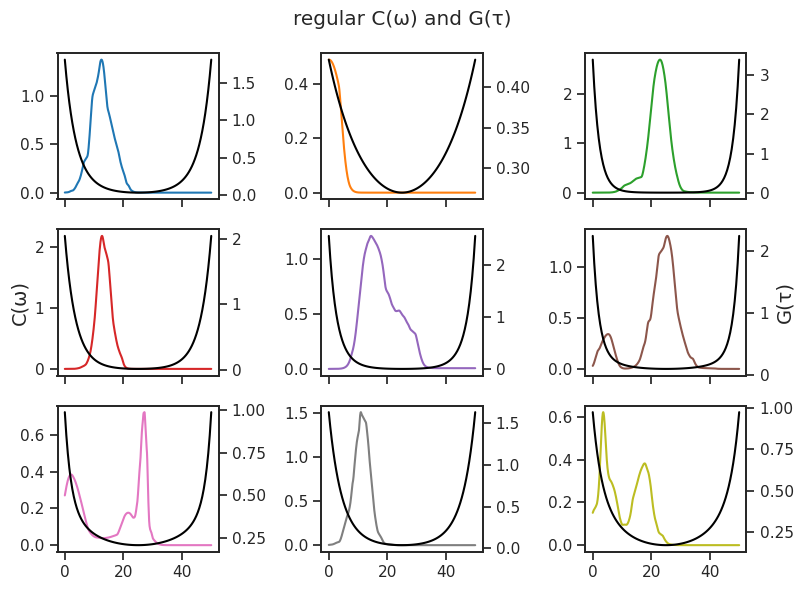

In [111]:
fig,axs = plt.subplots(3,3,figsize=(8.2,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax2= ax.twinx()
    ax2.plot(tau*omega[-1],(G_test[j]).view(99).cpu().detach().numpy(), color='k')
    if j==3:
        ax.set_ylabel('C(ω)')
    if j==5:
        ax2.set_ylabel('G(τ)')
fig.suptitle('regular C(ω) and G(τ)')
plt.tight_layout()
plt.show()

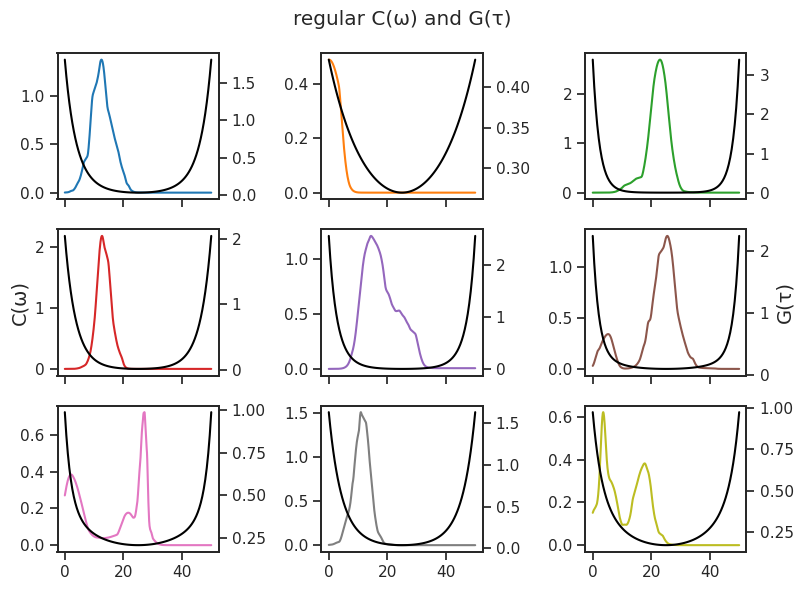

In [6]:
fig,axs = plt.subplots(3,3,figsize=(8.2,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax2= ax.twinx()
    ax2.plot(tau*omega[-1],(G_test_norm[j][0]).view(99).cpu().detach().numpy(), color='k')
    if j==3:
        ax.set_ylabel('C(ω)')
    if j==5:
        ax2.set_ylabel('G(τ)')
fig.suptitle('regular C(ω) and G(τ)')
plt.tight_layout()
plt.show()

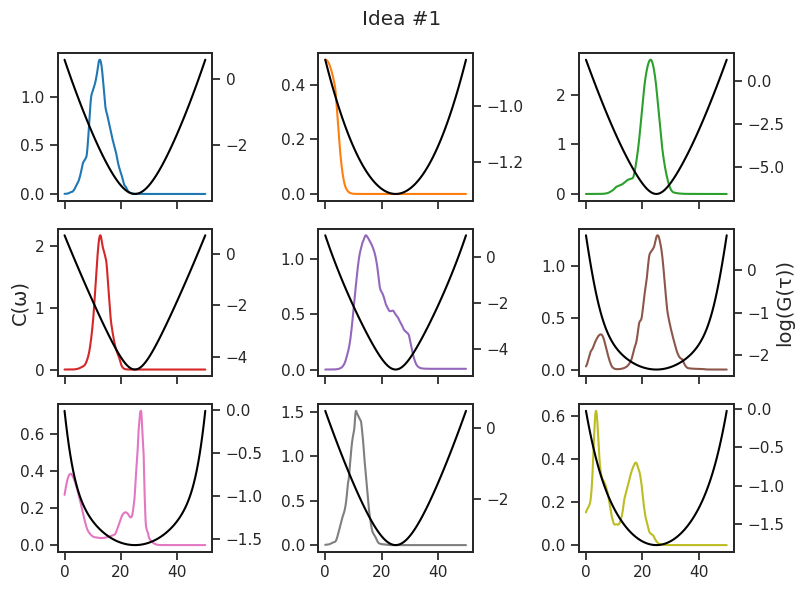

In [108]:
fig,axs = plt.subplots(3,3,figsize=(8.2,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax2= ax.twinx()
    ax2.plot(tau*omega[-1],torch.log(G_test[j]).view(99).cpu().detach().numpy(), color='k')
    if j==3:
        ax.set_ylabel('C(ω)')
    if j==5:
        ax2.set_ylabel('log(G(τ))')
fig.suptitle('Idea #1')
plt.tight_layout()
plt.show()

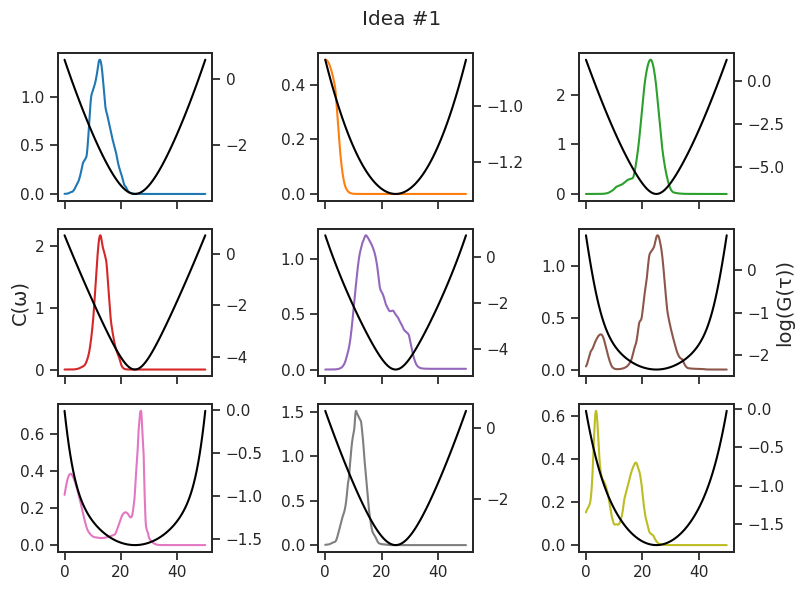

In [7]:
fig,axs = plt.subplots(3,3,figsize=(8.2,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax2= ax.twinx()
    ax2.plot(tau*omega[-1],(G_test_norm[j][1]).view(99).cpu().detach().numpy(), color='k')
    if j==3:
        ax.set_ylabel('C(ω)')
    if j==5:
        ax2.set_ylabel('log(G(τ))')
fig.suptitle('Idea #1')
plt.tight_layout()
plt.show()

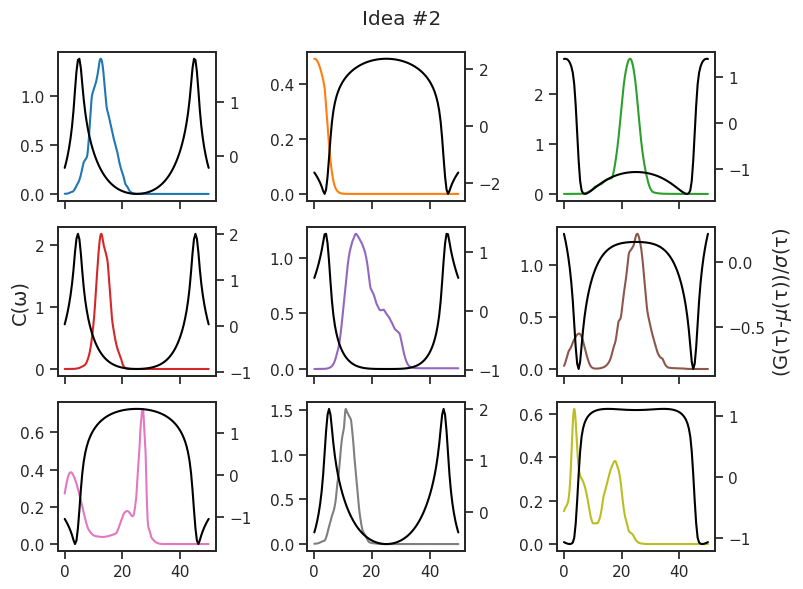

In [109]:
fig,axs = plt.subplots(3,3,figsize=(8.2,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax2= ax.twinx()
    ax2.plot(tau*omega[-1],((G_test[j]-pointwise_mean_G.unsqueeze(0))/pointwise_mean_abd_G.unsqueeze(0)).view(99).cpu().detach().numpy(), color='k')
    if j==3:
        ax.set_ylabel('C(ω)')
    if j==5:
        ax2.set_ylabel(r'(G(τ)-$\mu$(τ))/$\sigma$(τ)')
fig.suptitle('Idea #2')
plt.tight_layout()
plt.show()

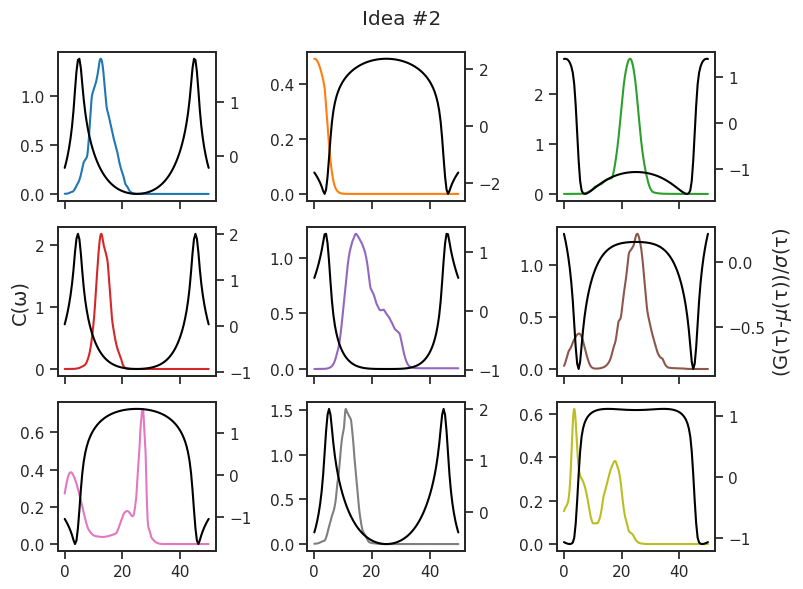

In [9]:
fig,axs = plt.subplots(3,3,figsize=(8.2,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax2= ax.twinx()
    ax2.plot(tau*omega[-1],(G_test_norm[j][2]).view(99).cpu().detach().numpy(), color='k')
    if j==3:
        ax.set_ylabel('C(ω)')
    if j==5:
        ax2.set_ylabel(r'(G(τ)-$\mu$(τ))/$\sigma$(τ)')
fig.suptitle('Idea #2')
plt.tight_layout()
plt.show()

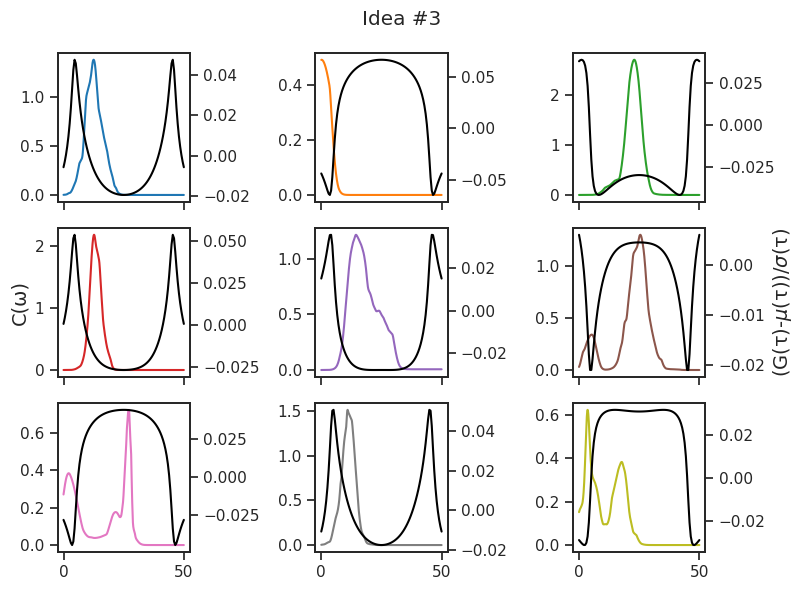

In [110]:
fig,axs = plt.subplots(3,3,figsize=(8.2,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax2= ax.twinx()
    ax2.plot(tau*omega[-1],((G_test[j]-pointwise_mean_G.unsqueeze(0))/pointwise_mean_std_G.unsqueeze(0)).view(99).cpu().detach().numpy(), color='k')
    if j==3:
        ax.set_ylabel('C(ω)')
    if j==5:
        ax2.set_ylabel(r'(G(τ)-$\mu$(τ))/$\sigma$(τ)')
fig.suptitle('Idea #3')
plt.tight_layout()
plt.show()

I obtain the pointwise CDF as follows:

$$
CDF_{\tau}(G')=\frac{1}{N}\sum_{i=1}^{N}I_{G_{i}(\tau)\leq G'}
$$

Here $I$ is the indicator function.

In [24]:
m = 10
L = len(dataloader)
possible_G_vals = np.linspace(0,6,int(1e5))
CDF = 0
for i in tqdm(range(m)):
    for C, G in dataloader:
        CDF += torch.tensor([((G<=i).sum(dim=(0,1))/len(G)/m/L).tolist() for i in possible_G_vals])

100%|██████████| 10/10 [23:24<00:00, 140.45s/it]


In [356]:
from scipy.interpolate import interp1d
interp_func = interp1d(torch.from_numpy(possible_G_vals), CDF, axis=0, kind='linear',bounds_error=False, fill_value='extrapolate')

In [415]:
def pointwise_CDF_of_G(G, possible_G_vals=possible_G_vals, CDF=CDF):
    # indices = [np.where(np.abs(possible_G_vals-i)<=0.5*possible_G_vals[1])[0] for i in G.flatten()]
    # return np.array([CDF[indices[i],i].item() for i in range(len(indices))])
    # CDF = CDF.cpu().detach().numpy()
    # return np.array([np.interp(g, possible_G_vals, CDF[:,i]) for i,g in enumerate(G.flatten())])
    indices = torch.searchsorted(torch.from_numpy(possible_G_vals),G)
    # return np.diag(interp_func(G))
    return torch.diag(CDF[indices,:])

In [ ]:
# np.save('rnd_spectra/cdf_G', CDF.cpu().detach().numpy())
# np.load('cdf_G.npy').shape

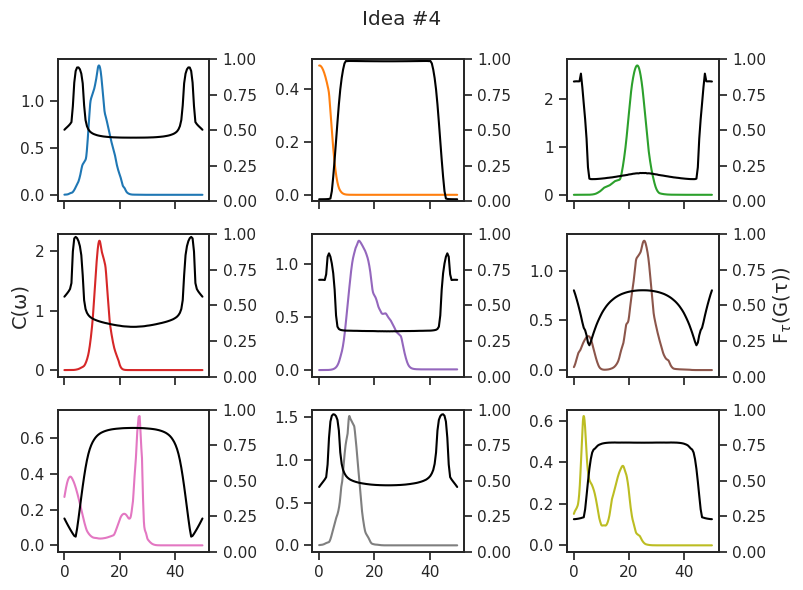

In [416]:
fig,axs = plt.subplots(3,3,figsize=(8.2,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax2= ax.twinx()
    ax2.plot(tau*omega[-1],pointwise_CDF_of_G((G_test[j]).view(99)), color='k')
    if j==3:
        ax.set_ylabel('C(ω)')
    if j==5:
        ax2.set_ylabel(r'F$_τ$(G(τ))')
    ax2.set_ylim(0,1)
fig.suptitle('Idea #4')
plt.tight_layout()
plt.show()

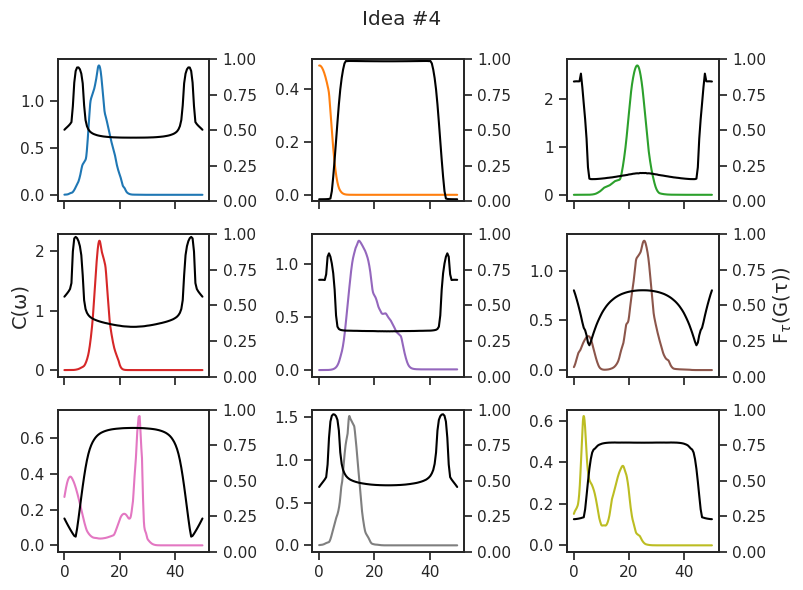

In [10]:
fig,axs = plt.subplots(3,3,figsize=(8.2,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax2= ax.twinx()
    ax2.plot(tau*omega[-1],((G_test_norm[j][3]).view(99)), color='k')
    if j==3:
        ax.set_ylabel('C(ω)')
    if j==5:
        ax2.set_ylabel(r'F$_τ$(G(τ))')
    ax2.set_ylim(0,1)
fig.suptitle('Idea #4')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'F$_{τ=0.5}$(G)')

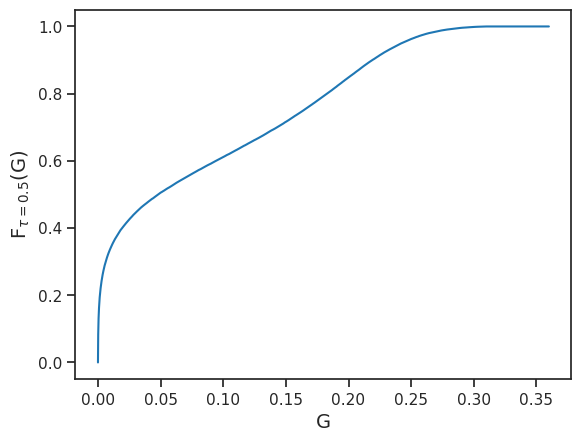

In [292]:
plt.plot(possible_G_vals[:6000],CDF[:6000,49])
plt.xlabel('G')
plt.ylabel('F$_{τ=0.5}$(G)')
# plt.xlim(0,2e-4)
# plt.xscale('log')

Text(0, 0.5, 'F$_{τ=0}$(G)')

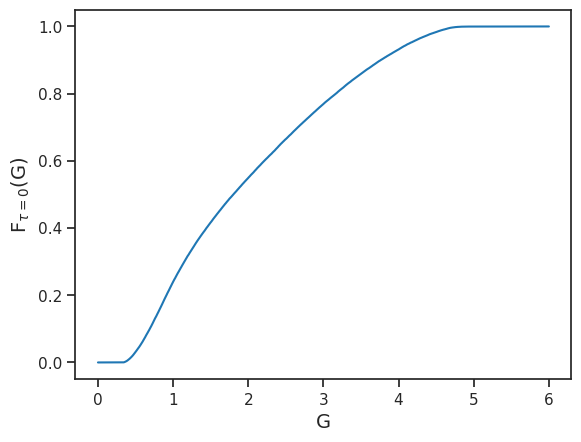

In [269]:
plt.plot(possible_G_vals[:],CDF[:,0])
plt.xlabel('G')
plt.ylabel('F$_{τ=0}$(G)')

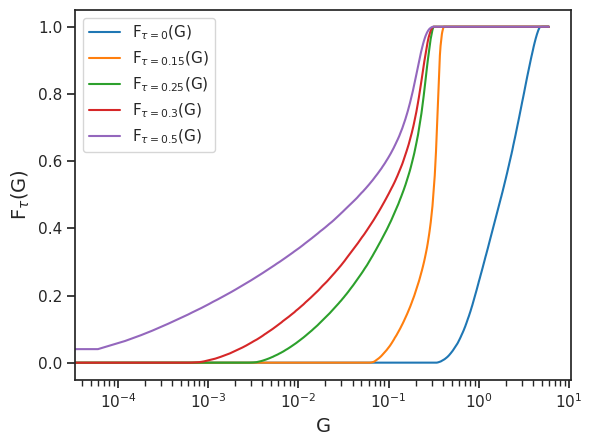

In [282]:
for itau in [0,0.15,0.25,0.3,0.5]:
    plt.plot(possible_G_vals,CDF[:,int(itau*99)], label=f'F$_{{τ={itau}}}$(G)')
plt.xlabel('G')
plt.ylabel('F$_{τ}$(G)')
plt.xscale('log')
plt.legend()

# Measure similarity

100%|██████████| 100/100 [12:40<00:00,  7.61s/it]


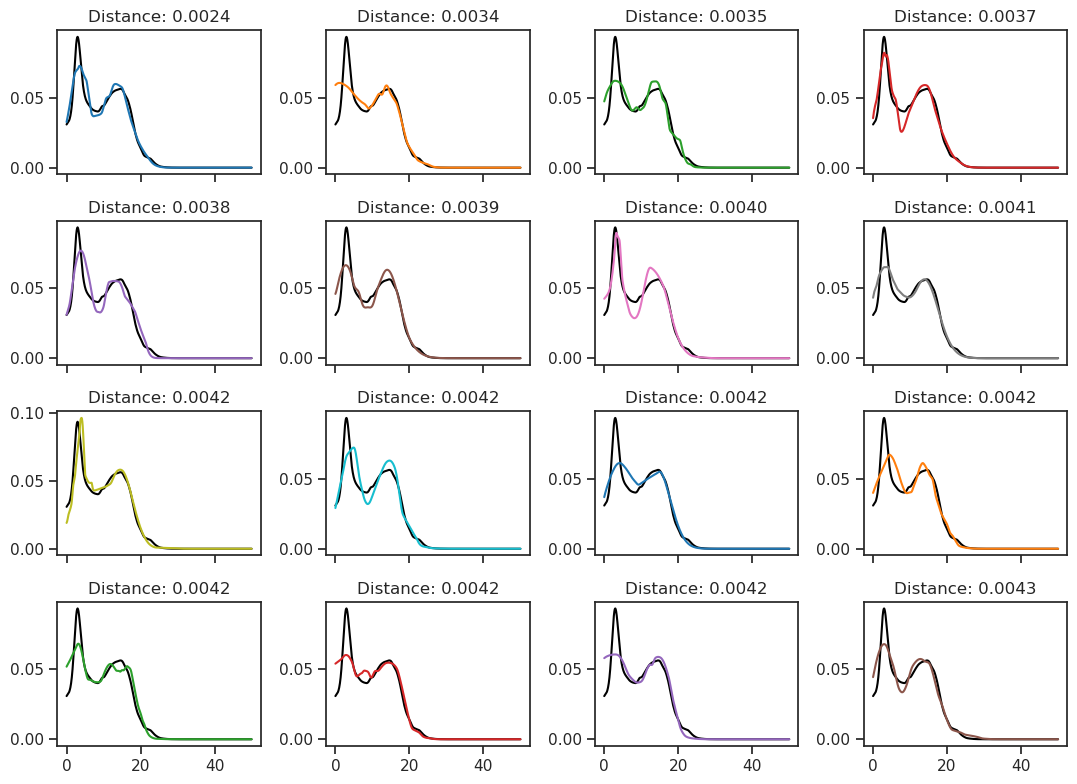

In [4]:
from similarity_metric import SimilarityMetric
sm = SimilarityMetric(hparams=hparams, specific_example=C_test[8],random_seed=20)
sm.sort_similarity(iterations=100)
sm.plot()

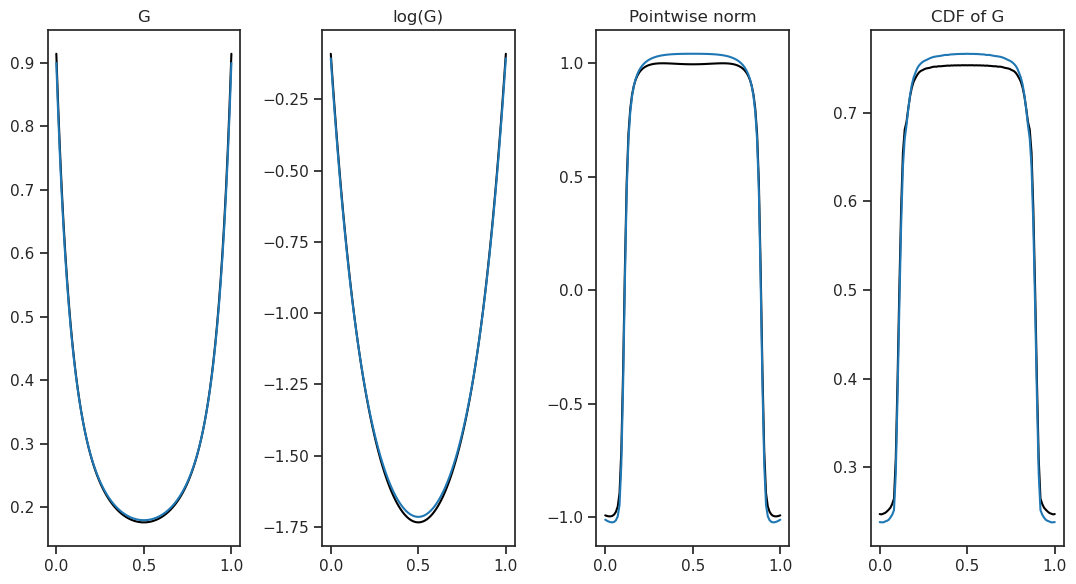

In [5]:
sm.plot_closest_G()

In [6]:
kB = 3.1668114E-6  # in Hartree/K
c = 2.99792458E10  # speed of light in cm/s
s_in_t_au = 2.4188843265857E-17  # 1 time a.u. in s

T = 14.0  # in K

b = 1 / (kB * T)
print('beta is ' + str(b))


tau = test_loader.dataset.laplace.tau
omega= test_loader.dataset.laplace.omega


# rabani output:
import pandas as pd
rabani_data = pd.read_csv("data/Rabani_D_w_14K.csv", sep=",", header=None)
rabani_data_w, rabani_data_D = rabani_data[0].values,rabani_data[1].values
rabani_data_w *= ( 2 * np.pi * c * s_in_t_au * b ) # now omega unitless
rabani_D_interp = np.interp(omega, rabani_data_w, rabani_data_D)
rabani_D_interp/= np.trapz(y=rabani_D_interp * (1-np.exp(-omega) + 1e-30)/(omega + 1e-30),x=omega)

beta is 22555.360078775586


100%|██████████| 100/100 [13:46<00:00,  8.27s/it]


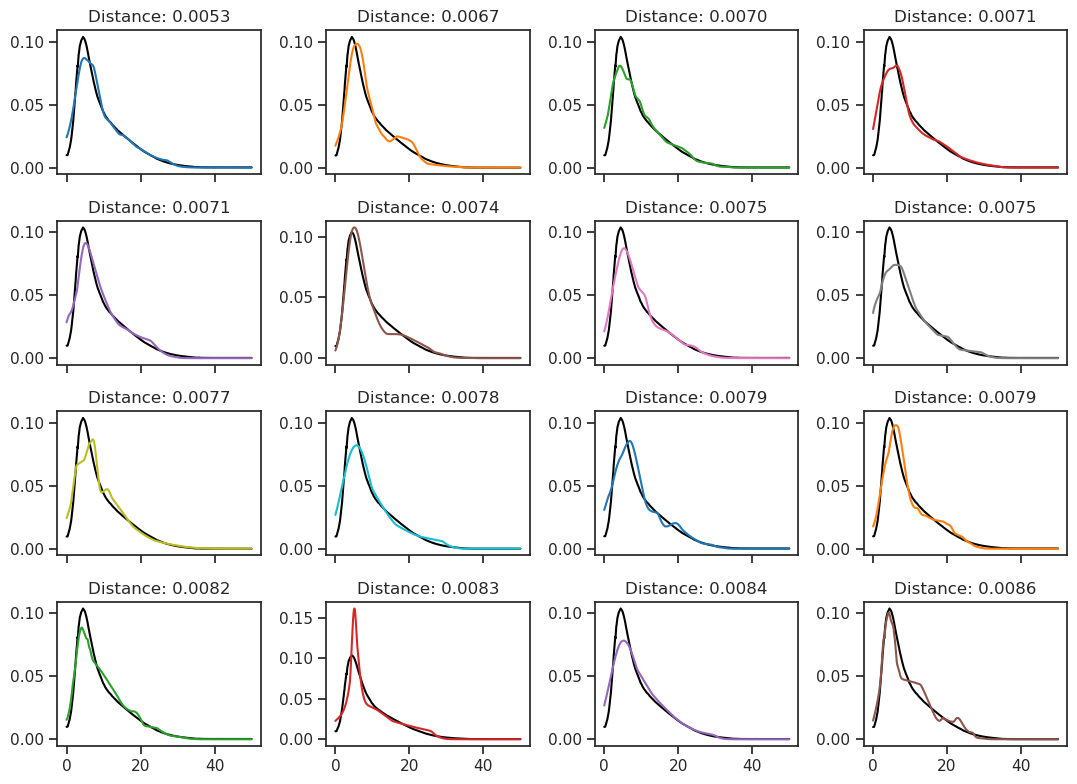

In [7]:
sm = SimilarityMetric(hparams=hparams, specific_example=torch.Tensor(rabani_D_interp),random_seed=40)
sm.sort_similarity(iterations=100)
sm.plot()

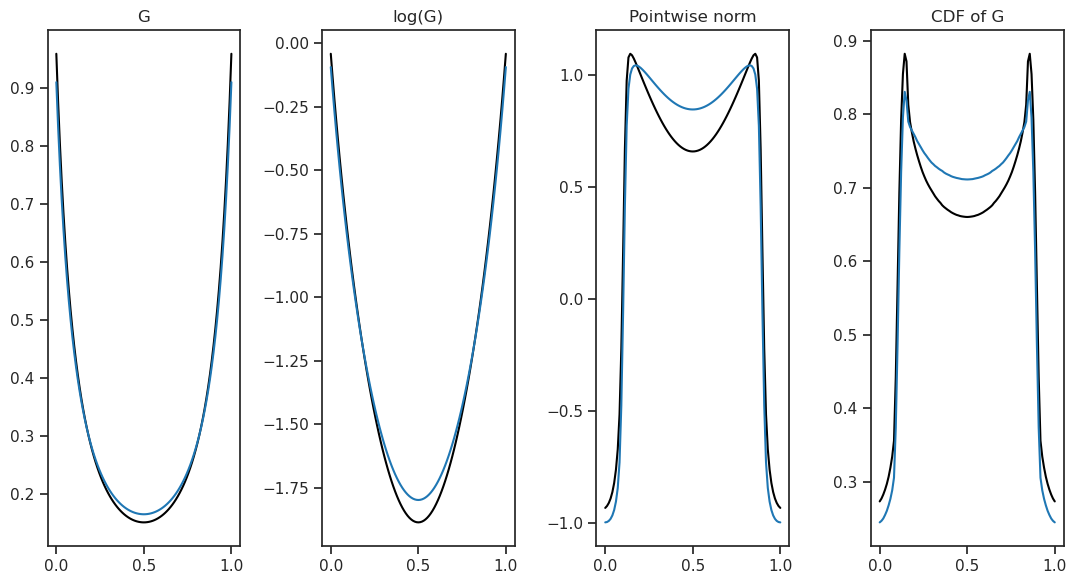

In [8]:
sm.plot_closest_G()

In [9]:
velFT = np.loadtxt('/home/sagi/Desktop/water/1bead/nve1/nve_facf.data', usecols=(0,1))
velFT = velFT[velFT[:,0] * 219474<=8000]
water_data_w, water_nve_D = velFT[:,0]* 219474 * ( 2 * np.pi * c * s_in_t_au /kB/300 ), velFT[:,1]
norm_water_nve_D=np.trapz(y=water_nve_D,x=water_data_w)
water_nve_D/=norm_water_nve_D
water_nve_D *= (water_data_w + 1E-30) / (1-np.exp(-water_data_w) + 1E-30)

water_nve_D_interp = np.interp(omega, water_data_w, water_nve_D)

100%|██████████| 100/100 [14:11<00:00,  8.52s/it]


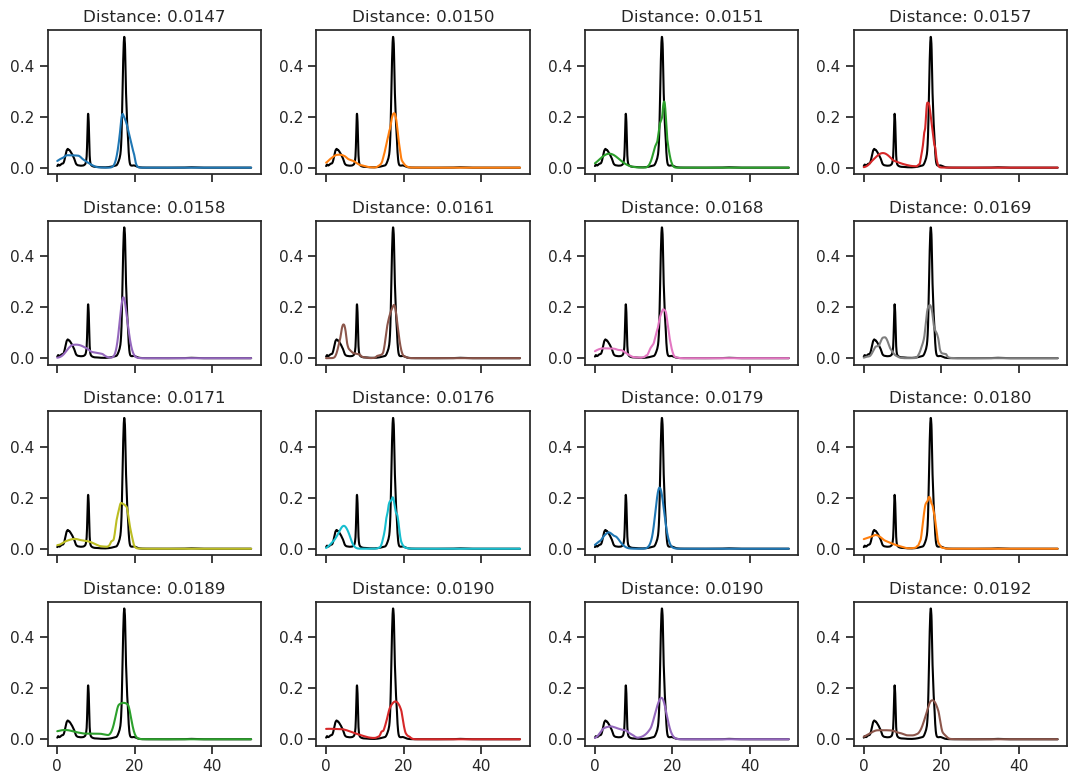

In [10]:
sm = SimilarityMetric(hparams=hparams, specific_example=torch.Tensor(water_nve_D_interp),random_seed=40)
sm.sort_similarity(iterations=100)
sm.plot()

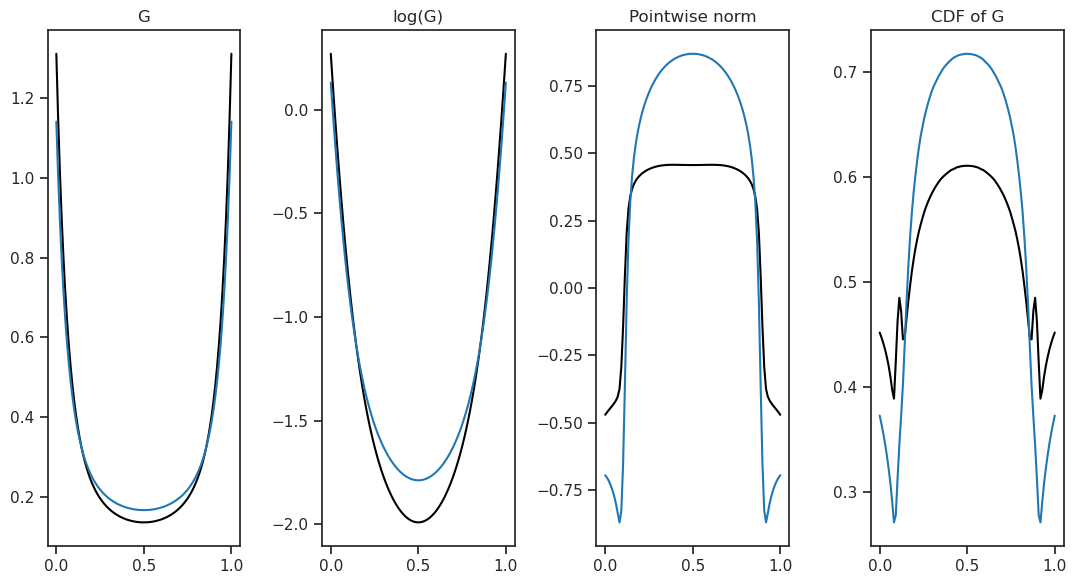

In [11]:
sm.plot_closest_G()